# *Loan Default Analysis and Prediction*  


### *Author*  
- Faiz Karol  


## *1. Business Problem*  

Loan defaults significantly impact the financial health of lending institutions, causing revenue losses and posing risks to sustainability. This project aims to minimize loan defaults while enhancing customer acquisition and profitability.

### *Key Objectives*:
1. *Identify* factors most strongly associated with loan defaults.  
2. *Develop* a predictive model to classify loan applicants into "default" or "non-default" categories.  
3. *Optimize* the loan approval process to balance risk and profitability.  

> The actionable insights and predictive model will empower better decision-making and risk management.  

---

## *2. Analytics Problem*  

To achieve the business objectives, the following analytics tasks have been defined:  
1. Perform *detailed data analysis* to identify trends and patterns.  
2. Analyze relationships between *applicant characteristics* and loan defaults.  
3. Build and evaluate *predictive models* to classify loan applications effectively.

The analysis will focus on leveraging the dataset to generate actionable insights for optimizing the loan approval process.

---

## *3. Data Description and Allocation*  

### *Dataset Overview*
- *Source*: Loan_Dataset.csv  
- *Number of Observations*: Approximately 2200 records  
- *Key Features*:  
  - *Financial Details*: Income, credit history, debt-to-income ratio  
  - *Loan Characteristics*: Loan amount, term, interest rate  
  - *Target Variable*: Loan status (default or non-default)  

#### *Challenges*  
- Missing values in features such as employment history and income.  
- Need for feature transformation and imputation for robust modeling.  

---

### *Resource Allocation*
- *Infrastructure*: Local systems with Python-based data analysis tools.  
- *Personnel*: One data analyst for EDA, modeling, and reporting.  
- *Timeframe*:  
  - *2 weeks* for analysis and modeling.  
  - *1 week* for validation and deployment recommendations.  

---

> ### *Notebook Features*  
> This notebook will include:  
> - Clear markdown for documentation and structure.  
> - Well-commented Python code for analysis and modeling.  
> - Visualizations (using libraries like Matplotlib and Seaborn) to explore data patterns.  
> - Detailed model evaluation metrics to assess performance.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb



warnings.filterwarnings('ignore')

In [5]:
df=pd.read_csv('PATH/Loan_Dataset.csv')

### *Exploratory Data Analysis (EDA)* 

In [6]:
df.head()

,ID,Amount.Requested,Amount.Funded.By.Investors,Interest.Rate,Loan.Length,Loan.Purpose,Debt.To.Income.Ratio,State,Home.Ownership,Monthly.Income,FICO.Range,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.in.the.Last.6.Months,Employment.Length,Default
0,79542.0,25000,25000,18.49%,60 months,debt_consolidation,27.56%,VA,MORTGAGE,8606.56,720-724,11,15210,3.0,5 years,1
1,75473.0,19750,19750,17.27%,60 months,debt_consolidation,13.39%,NY,MORTGAGE,6737.50,710-714,14,19070,3.0,4 years,0
2,67265.0,2100,2100,14.33%,36 months,major_purchase,3.50%,LA,OWN,1000.00,690-694,13,893,1.0,< 1 year,0
3,80167.0,28000,28000,16.29%,36 months,credit_card,19.62%,NV,MORTGAGE,7083.33,710-714,12,38194,1.0,10+ years,0
4,17240.0,24250,17431.82,12.23%,60 months,credit_card,23.79%,OH,MORTGAGE,5833.33,730-734,6,31061,2.0,10+ years,0


In [7]:
df.shape

(2200, 16)

In [8]:
df.columns

Index(['ID', 'Amount.Requested', 'Amount.Funded.By.Investors', 'Interest.Rate',
       'Loan.Length', 'Loan.Purpose', 'Debt.To.Income.Ratio', 'State',
       'Home.Ownership', 'Monthly.Income', 'FICO.Range', 'Open.CREDIT.Lines',
       'Revolving.CREDIT.Balance', 'Inquiries.in.the.Last.6.Months',
       'Employment.Length', 'Default'],
      dtype='object')

In [9]:
df.columns=df.columns.str.replace('.','_')

#### *Coverting columns to appropriate datatype*

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              2199 non-null   float64
 1   Amount_Requested                2199 non-null   object 
 2   Amount_Funded_By_Investors      2199 non-null   object 
 3   Interest_Rate                   2200 non-null   object 
 4   Loan_Length                     2199 non-null   object 
 5   Loan_Purpose                    2199 non-null   object 
 6   Debt_To_Income_Ratio            2199 non-null   object 
 7   State                           2199 non-null   object 
 8   Home_Ownership                  2199 non-null   object 
 9   Monthly_Income                  2197 non-null   float64
 10  FICO_Range                      2200 non-null   object 
 11  Open_CREDIT_Lines               2196 non-null   object 
 12  Revolving_CREDIT_Balance        21

In [11]:
df.Amount_Requested=pd.to_numeric(df.Amount_Requested,errors='coerce')

In [12]:
df.Amount_Funded_By_Investors=pd.to_numeric(df.Amount_Funded_By_Investors,errors='coerce')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              2199 non-null   float64
 1   Amount_Requested                2195 non-null   float64
 2   Amount_Funded_By_Investors      2196 non-null   float64
 3   Interest_Rate                   2200 non-null   object 
 4   Loan_Length                     2199 non-null   object 
 5   Loan_Purpose                    2199 non-null   object 
 6   Debt_To_Income_Ratio            2199 non-null   object 
 7   State                           2199 non-null   object 
 8   Home_Ownership                  2199 non-null   object 
 9   Monthly_Income                  2197 non-null   float64
 10  FICO_Range                      2200 non-null   object 
 11  Open_CREDIT_Lines               2196 non-null   object 
 12  Revolving_CREDIT_Balance        21

#### *Removing Irrevelant Characters*

In [14]:
df.Interest_Rate

0       18.49%
1       17.27%
2       14.33%
3       16.29%
4       12.23%
         ...  
2195    23.28%
2196    14.33%
2197    15.31%
2198    20.99%
2199    10.16%
Name: Interest_Rate, Length: 2200, dtype: object

In [15]:
df.Interest_Rate=df.Interest_Rate.str.strip('%').astype(float)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              2199 non-null   float64
 1   Amount_Requested                2195 non-null   float64
 2   Amount_Funded_By_Investors      2196 non-null   float64
 3   Interest_Rate                   2200 non-null   float64
 4   Loan_Length                     2199 non-null   object 
 5   Loan_Purpose                    2199 non-null   object 
 6   Debt_To_Income_Ratio            2199 non-null   object 
 7   State                           2199 non-null   object 
 8   Home_Ownership                  2199 non-null   object 
 9   Monthly_Income                  2197 non-null   float64
 10  FICO_Range                      2200 non-null   object 
 11  Open_CREDIT_Lines               2196 non-null   object 
 12  Revolving_CREDIT_Balance        21

In [17]:
df.loc[df.Loan_Length=='.','Loan_Length']=np.nan

In [18]:
df.Loan_Length=df.Loan_Length.str.replace(r'[a-z]+','',regex=True).astype(float)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              2199 non-null   float64
 1   Amount_Requested                2195 non-null   float64
 2   Amount_Funded_By_Investors      2196 non-null   float64
 3   Interest_Rate                   2200 non-null   float64
 4   Loan_Length                     2198 non-null   float64
 5   Loan_Purpose                    2199 non-null   object 
 6   Debt_To_Income_Ratio            2199 non-null   object 
 7   State                           2199 non-null   object 
 8   Home_Ownership                  2199 non-null   object 
 9   Monthly_Income                  2197 non-null   float64
 10  FICO_Range                      2200 non-null   object 
 11  Open_CREDIT_Lines               2196 non-null   object 
 12  Revolving_CREDIT_Balance        21

In [20]:
df.Debt_To_Income_Ratio

0       27.56%
1       13.39%
2        3.50%
3       19.62%
4       23.79%
         ...  
2195    12.10%
2196    14.16%
2197    15.03%
2198    11.63%
2199     3.83%
Name: Debt_To_Income_Ratio, Length: 2200, dtype: object

In [21]:
df.Debt_To_Income_Ratio=df.Debt_To_Income_Ratio.str.strip('%').astype(float)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              2199 non-null   float64
 1   Amount_Requested                2195 non-null   float64
 2   Amount_Funded_By_Investors      2196 non-null   float64
 3   Interest_Rate                   2200 non-null   float64
 4   Loan_Length                     2198 non-null   float64
 5   Loan_Purpose                    2199 non-null   object 
 6   Debt_To_Income_Ratio            2199 non-null   float64
 7   State                           2199 non-null   object 
 8   Home_Ownership                  2199 non-null   object 
 9   Monthly_Income                  2197 non-null   float64
 10  FICO_Range                      2200 non-null   object 
 11  Open_CREDIT_Lines               2196 non-null   object 
 12  Revolving_CREDIT_Balance        21

In [23]:
df.FICO_Range

0       720-724
1       710-714
2       690-694
3       710-714
4       730-734
         ...   
2195    675-679
2196    700-704
2197    675-679
2198    670-674
2199    710-714
Name: FICO_Range, Length: 2200, dtype: object

In [24]:
fico=df.FICO_Range.str.split('-',expand=True).astype(int)
fico.columns=['Min','Max']


In [25]:
fico

,Min,Max
0,720,724
1,710,714
2,690,694
3,710,714
4,730,734
...,...,...
2195,675,679
2196,700,704
2197,675,679
2198,670,674


In [26]:
df.FICO_Range=(fico.Min+fico.Max)/2

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              2199 non-null   float64
 1   Amount_Requested                2195 non-null   float64
 2   Amount_Funded_By_Investors      2196 non-null   float64
 3   Interest_Rate                   2200 non-null   float64
 4   Loan_Length                     2198 non-null   float64
 5   Loan_Purpose                    2199 non-null   object 
 6   Debt_To_Income_Ratio            2199 non-null   float64
 7   State                           2199 non-null   object 
 8   Home_Ownership                  2199 non-null   object 
 9   Monthly_Income                  2197 non-null   float64
 10  FICO_Range                      2200 non-null   float64
 11  Open_CREDIT_Lines               2196 non-null   object 
 12  Revolving_CREDIT_Balance        21

In [28]:
df.Open_CREDIT_Lines=pd.to_numeric(df.Open_CREDIT_Lines,errors='coerce')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              2199 non-null   float64
 1   Amount_Requested                2195 non-null   float64
 2   Amount_Funded_By_Investors      2196 non-null   float64
 3   Interest_Rate                   2200 non-null   float64
 4   Loan_Length                     2198 non-null   float64
 5   Loan_Purpose                    2199 non-null   object 
 6   Debt_To_Income_Ratio            2199 non-null   float64
 7   State                           2199 non-null   object 
 8   Home_Ownership                  2199 non-null   object 
 9   Monthly_Income                  2197 non-null   float64
 10  FICO_Range                      2200 non-null   float64
 11  Open_CREDIT_Lines               2193 non-null   float64
 12  Revolving_CREDIT_Balance        21

In [30]:
df.Revolving_CREDIT_Balance=pd.to_numeric(df.Revolving_CREDIT_Balance,errors='coerce')

In [31]:
df.Employment_Length=df.Employment_Length.str.replace(r'[a-z<+]+','',regex=True)

In [32]:
df.Employment_Length=pd.to_numeric(df.Employment_Length,errors='coerce')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              2199 non-null   float64
 1   Amount_Requested                2195 non-null   float64
 2   Amount_Funded_By_Investors      2196 non-null   float64
 3   Interest_Rate                   2200 non-null   float64
 4   Loan_Length                     2198 non-null   float64
 5   Loan_Purpose                    2199 non-null   object 
 6   Debt_To_Income_Ratio            2199 non-null   float64
 7   State                           2199 non-null   object 
 8   Home_Ownership                  2199 non-null   object 
 9   Monthly_Income                  2197 non-null   float64
 10  FICO_Range                      2200 non-null   float64
 11  Open_CREDIT_Lines               2193 non-null   float64
 12  Revolving_CREDIT_Balance        21

### *Null Imputation*

In [34]:
df.isna().sum()

ID                                 1
Amount_Requested                   5
Amount_Funded_By_Investors         4
Interest_Rate                      0
Loan_Length                        2
Loan_Purpose                       1
Debt_To_Income_Ratio               1
State                              1
Home_Ownership                     1
Monthly_Income                     3
FICO_Range                         0
Open_CREDIT_Lines                  7
Revolving_CREDIT_Balance           5
Inquiries_in_the_Last_6_Months     3
Employment_Length                 70
Default                            0
dtype: int64

In [35]:
num_col=[]
cat_col=[]
for i in df.columns:
    if (df[i].dtype==float or df[i].dtype==int) and df[i].nunique()>5:
        num_col.append(i)
    else:
        cat_col.append(i)

In [36]:
num_col

['ID',
 'Amount_Requested',
 'Amount_Funded_By_Investors',
 'Interest_Rate',
 'Debt_To_Income_Ratio',
 'Monthly_Income',
 'FICO_Range',
 'Open_CREDIT_Lines',
 'Revolving_CREDIT_Balance',
 'Inquiries_in_the_Last_6_Months',
 'Employment_Length']

In [37]:
cat_col

['Loan_Length', 'Loan_Purpose', 'State', 'Home_Ownership', 'Default']

In [38]:
def null_imput_num(col):
    df.loc[df[col].isna(),col]=df[col].mean()
def null_imput_cat(col):
    df.loc[df[col].isna(),col]=df[col].mode()[0]

In [39]:
for i in num_col:
    null_imput_num(i)
for j in cat_col:
    null_imput_cat(j)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              2200 non-null   float64
 1   Amount_Requested                2200 non-null   float64
 2   Amount_Funded_By_Investors      2200 non-null   float64
 3   Interest_Rate                   2200 non-null   float64
 4   Loan_Length                     2200 non-null   float64
 5   Loan_Purpose                    2200 non-null   object 
 6   Debt_To_Income_Ratio            2200 non-null   float64
 7   State                           2200 non-null   object 
 8   Home_Ownership                  2200 non-null   object 
 9   Monthly_Income                  2200 non-null   float64
 10  FICO_Range                      2200 non-null   float64
 11  Open_CREDIT_Lines               2200 non-null   float64
 12  Revolving_CREDIT_Balance        22

### *Visualization*

In [ ]:
df.hist(figsize=(15, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numeric Columns Using Pandas')
plt.show()

In [ ]:
home_ownership_counts = df['Home_Ownership'].value_counts()
plt.figure(figsize=(10, 8))
plt.pie(home_ownership_counts, labels=home_ownership_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Home Ownership Distribution')
plt.tight_layout() 
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap Using seaborn')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Monthly_Income', y='Interest_Rate', data=df, alpha=0.6)
sns.regplot(x='Monthly_Income', y='Interest_Rate', data=df, scatter=False, color='red')
plt.title('Seaborn: Monthly Income vs Interest Rate')
plt.show()

In [42]:
df['Amount_Difference'] = df['Amount_Requested'] - df['Amount_Funded_By_Investors']
df['Funding_Ratio'] = df['Amount_Funded_By_Investors'] / df['Amount_Requested']
df['Monthly_Debt_Ratio'] = (df['Revolving_CREDIT_Balance'] * df['Interest_Rate']) / (12 * 100 * df['Monthly_Income'])
df['Credit_Line_Ratio'] = df['Revolving_CREDIT_Balance'] / df['Open_CREDIT_Lines']


In [43]:
data=df.copy()

In [44]:
encoder = LabelEncoder()
categorical_cols = ['Loan_Length', 'Loan_Purpose', 'Home_Ownership', 'Employment_Length']
for col in categorical_cols:
    data[f'{col}_encoded'] = encoder.fit_transform(data[col])

In [45]:
X = data[['Interest_Rate', 'Debt_To_Income_Ratio', 'FICO_Range', 
          'Inquiries_in_the_Last_6_Months', 'Employment_Length_encoded', 
          'Loan_Length_encoded', 'Loan_Purpose_encoded', 
          'Home_Ownership_encoded', 'Amount_Difference', 'Funding_Ratio', 
          'Monthly_Debt_Ratio', 'Credit_Line_Ratio']]

y_classification = data['Default']
y_regression = data['Amount_Difference']



In [46]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y_classification, test_size=0.3, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_regression, test_size=0.3, random_state=42)



In [47]:
rf_classifier = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_classifier.fit(X_train_class, y_train_class)

y_pred_class = rf_classifier.predict(X_test_class)
print("\nClassification Report (Predicting Default):")
print(classification_report(y_test_class, y_pred_class))
print("Confusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_class))




Classification Report (Predicting Default):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       596
           1       1.00      0.88      0.93        64

    accuracy                           0.99       660
   macro avg       0.99      0.94      0.96       660
weighted avg       0.99      0.99      0.99       660

Confusion Matrix:
[[596   0]
 [  8  56]]


In [48]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)


y_pred_reg = lin_reg.predict(X_test_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print(f"\nRegression RMSE (Predicting Amount Difference): {rmse:.2f}")





Regression RMSE (Predicting Amount Difference): 0.00


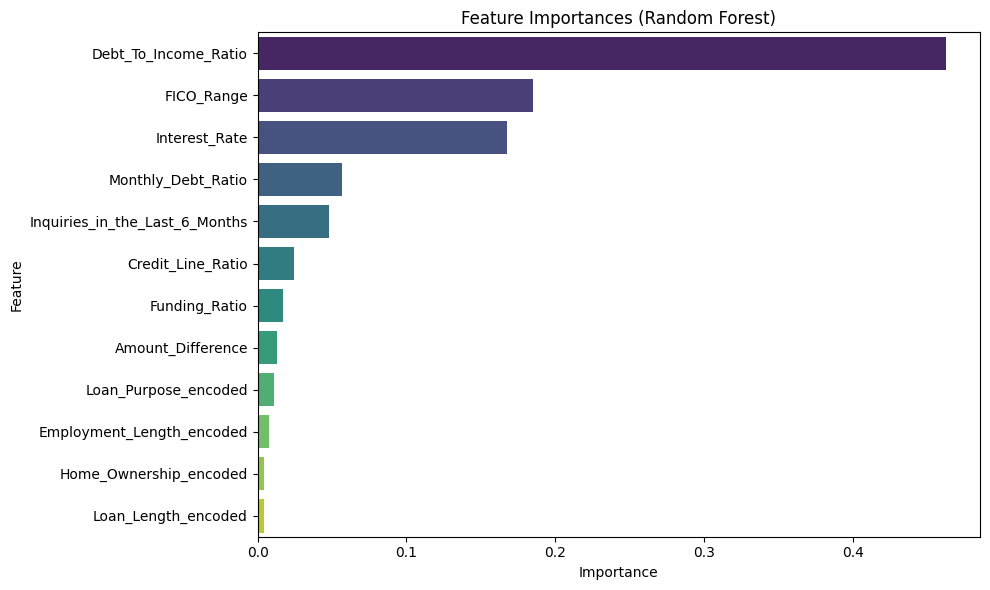

In [51]:
feature_importances = pd.DataFrame({'Feature': X.columns, 
                                    'Importance': rf_classifier.feature_importances_}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette="viridis")
plt.title("Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

### 6. Conclusions and Recommendations

1. *Key Findings*:
   - Credit score and debt-to-income ratio are the most critical indicators of default risk.
   - Applicants with high loan amounts relative to income are at higher risk.
   - Employment stability and length also influence loan outcomes.

2. *Recommendations*:
   - Implement stricter credit score thresholds to mitigate risk.
   - Introduce financial literacy workshops for applicants to improve debt management.
   - Integrate the predictive model into the loan processing system to flag high-risk applicants for additional review.

3. *Operational Changes*:
   - Adjust marketing strategies to target low-risk demographics.
   - Consider offering flexible repayment terms for high-risk but promising applicants to improve repayment likelihood.

*Next Steps*:
- Perform additional validation of the models using external data sources.
- Deploy the predictive model within the loan processing workflow.
- Continuously monitor model performance and update based on new data trends.

By implementing these strategies, the institution can reduce defaults, improve profitability, and enhance overall customer satisfaction.?

### *What More Data Would Allow*

Following are some enhancements that could be done to the analysis and modeling with more data:

Incorporate Behavioral Data: Spending habits, payment history, frequency of transactions.
These would greatly contribute to the refinement of the risk assessment process and the detection of hidden trends in defaults.

Greater Feature Diversity: Applicant's educational background, industry employed in, and financial obligations such as mortgages or other loans. Broader feature sets would likely improve predictive accuracy and provide richer insights.

Temporal Analysis: Include time-series data that will help to track applicant behavior and loan performance over time. Analyze seasonal trends or macroeconomic influences on default rates.

Segmented Analysis: With more data, perform segmented analysis by demographics, loan types, or geographic regions.
This would allow pinpointing specific customer groups that have different levels of risk.

Larger-Scale Validation: Validate models with data from diverse institutions or regions. Generalization and Robustness: Ensure the generalizability and robustness of models across different contexts. 

Machine Learning Enhancements: Train more sophisticated models, such as neural networks or ensemble methods, on larger datasets. Apply techniques such as hyperparameter tuning and feature selection to optimize the performance. Integrate External Data Sources:

Integrate internal data with external sources, including credit bureau scores, economic indicators, and social media insights. This would provide a more complete picture of applicant risk and further enhance the model.

Deep Dive into Missing Data: Use larger data sets to develop an analysis of the missing data patterns to look for systemic problems. Build better imputation models or improve methods of data collection in the first place for better representation of missing values. This would bring more actionable insights, which, in turn, could bring much more accuracy to the risk models' predictions and set better strategies targeting loans.